This notebook combines multiple detection signals to generate a
composite transaction risk score used for financial crime monitoring.

Signals used:

• Fraud detection model probability

• Behavioral anomaly score

• Transaction amount risk

The final output is a transaction risk score (0–100) used to prioritize
alerts for investigation in financial crime monitoring systems.


In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load Dataset
PATH = r'D:\Project code\financial-crime-ai\data\creditcard.csv'
data = pd.read_csv(PATH)

print(data.shape)
data.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Load Trained Models
fraud_model = joblib.load("../models/fraud_detection_model.pkl")

anomaly_model = joblib.load("../models/anomaly_detection_model.pkl")

In [4]:
# Prepare Features
X = data.drop("Class", axis=1)
y = data["Class"]

In [5]:
# Generate Fraud Probabilities
fraud_probabilities = fraud_model.predict_proba(X)[:,1]

In [6]:
# Add to dataframe
data["fraud_probability"] = fraud_probabilities

In [7]:
# Check distribution
data["fraud_probability"].describe()

count    284807.000000
mean          0.001666
std           0.036524
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: fraud_probability, dtype: float64

In [9]:
# Generate Anomaly Scores
anomaly_scores = anomaly_model.decision_function(X)

data["anomaly_score"] = anomaly_scores

In [10]:
# Lower score = more suspicious.
data["anomaly_risk"] = data["anomaly_score"].max() - data["anomaly_score"]

In [11]:
# Convert to risk:
data["anomaly_risk"] = data["anomaly_score"].max() - data["anomaly_score"]

In [12]:
# Normalize Signals
scaler = MinMaxScaler()

In [13]:
# Normalize fraud probability
data["fraud_probability"] = scaler.fit_transform(
    data[["fraud_probability"]]
)

In [14]:
# Normalize anomaly risk
data["anomaly_risk"] = scaler.fit_transform(
    data[["anomaly_risk"]]
)

In [15]:
# Normalize amount risk
data["amount_risk"] = scaler.fit_transform(
    data[["Amount"]]
)

In [ ]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,fraud_probability,anomaly_score,anomaly_risk,amount_risk
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0.269253,0.070360,0.005824
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0.276914,0.052408,0.000105
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,0.185157,0.267418,0.014739
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,0.246072,0.124680,0.004807
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,0.258155,0.096367,0.002724


| Signal             | Weight |
| ------------------ | ------ |
| Fraud model        | 50%    |
| Anomaly detection  | 30%    |
| Transaction amount | 20%    |


In [17]:
# Build Composite Risk Score
data["risk_score"] = (
    0.5 * data["fraud_probability"] +
    0.3 * data["anomaly_risk"] +
    0.2 * data["amount_risk"]
)

In [ ]:
data["risk_score"].head()

0    0.022273
1    0.015743
2    0.083173
3    0.038365
4    0.029455
Name: risk_score, dtype: float64

In [20]:
# Scale to 0–100
data["risk_score"] = data["risk_score"] * 100

In [21]:
# Inspect results
data[["fraud_probability","anomaly_risk","amount_risk","risk_score"]].head()

,fraud_probability,anomaly_risk,amount_risk,risk_score
0,0.0,0.070360,0.005824,2.227288
1,0.0,0.052408,0.000105,1.574336
2,0.0,0.267418,0.014739,8.317319
3,0.0,0.124680,0.004807,3.836538
4,0.0,0.096367,0.002724,2.945486


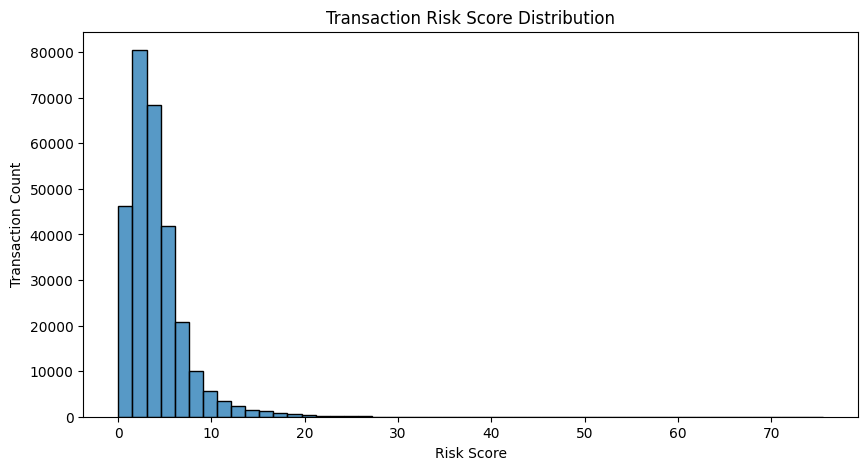

In [22]:
# Risk Score Distribution
plt.figure(figsize=(10,5))

sns.histplot(data["risk_score"], bins=50)

plt.title("Transaction Risk Score Distribution")

plt.xlabel("Risk Score")

plt.ylabel("Transaction Count")

plt.show()

In [23]:
# Highest Risk Transactions
alerts = data.sort_values(
    "risk_score",
    ascending=False
)

alerts.head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V26,V27,V28,Amount,Class,fraud_probability,anomaly_score,anomaly_risk,amount_risk,risk_score
153823,100223.0,-19.641857,14.706335,-22.801238,12.114672,-14.898113,0.840778,-28.011293,-11.919639,-8.960922,...,0.038423,-4.126746,-0.645329,2.28,1,0.995,-0.067571,0.859622,0.000089,75.540421
151008,94362.0,-26.457745,16.497472,-30.177317,8.904157,-17.892600,-1.227904,-31.197329,-11.438920,-9.462573,...,-0.966564,-7.263482,-1.324884,1.00,1,0.990,-0.067990,0.860604,0.000039,75.318911
151006,94362.0,-26.457745,16.497472,-30.177317,8.904157,-17.892600,-1.227904,-31.197329,-11.438920,-9.462573,...,-0.966564,-7.263482,-1.324884,1.00,1,0.990,-0.067990,0.860604,0.000039,75.318911
151009,94362.0,-26.457745,16.497472,-30.177317,8.904157,-17.892600,-1.227904,-31.197329,-11.438920,-9.462573,...,-0.966564,-7.263482,-1.324884,1.00,1,0.990,-0.067990,0.860604,0.000039,75.318911
151007,94362.0,-26.457745,16.497472,-30.177317,8.904157,-17.892600,-1.227904,-31.197329,-11.438920,-9.462573,...,-0.966564,-7.263482,-1.324884,1.00,1,0.990,-0.067990,0.860604,0.000039,75.318911
43204,41413.0,-15.140450,7.378042,-16.356367,9.194935,-13.466163,-2.958431,-16.165539,10.075254,-7.901821,...,0.145964,-2.458680,-1.189888,106.55,1,0.995,-0.056228,0.833042,0.004147,74.824217
102442,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,-0.108877,1.269566,0.939407,1.00,1,0.975,-0.069470,0.864072,0.000039,74.672926
102444,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,-0.108877,1.269566,0.939407,1.00,1,0.975,-0.069470,0.864072,0.000039,74.672926
102445,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,-0.108877,1.269566,0.939407,1.00,1,0.975,-0.069470,0.864072,0.000039,74.672926
102446,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,-0.108877,1.269566,0.939407,1.00,1,0.975,-0.069470,0.864072,0.000039,74.672926


In [24]:
# Flag high-risk transactions
alerts = data[data["risk_score"] > 60]

print("Number of High Risk Alerts:", len(alerts))

Number of High Risk Alerts: 318


In [25]:
# Fraud Detection within Alerts
fraud_alerts = alerts[alerts["Class"] == 1]

print("Fraud transactions detected:", len(fraud_alerts))

Fraud transactions detected: 316


In [ ]:
# Alert Rate
alert_rate = len(alerts) / len(data)

print("Alert Rate:", alert_rate)
# Banks usually keep alert rates between: 0.5% – 5% of transactions

Alert Rate: 0.0011165455905227048


In [29]:
# Fraud Capture Rate
fraud_capture_rate = len(alerts[alerts["Class"]==1]) / sum(data["Class"])

print("Fraud Capture Rate:", fraud_capture_rate*100)

Fraud Capture Rate: 64.22764227642277


In [27]:
# Save Alert Dataset
alerts.to_csv("../data/high_risk_alerts.csv", index=False)
# This file simulates the investigation queue used by fraud analysts.

### Key Insights

The risk scoring system generated 318 high-risk alerts, capturing
316 fraudulent transactions out of 492 total fraud cases in the dataset.

This corresponds to a fraud detection rate of approximately 64%.
The system achieved very high precision, with only two false positive alerts.

The alert rate was approximately 0.11% of total transactions,
which indicates a highly selective alert prioritization strategy.
Such prioritization helps reduce investigation workload while
still capturing the majority of fraudulent transactions.